### Burger's equation
For a given field $u(x,t)$ and diffusion coefficient (or kinematic viscosity, as in the original fluid mechanical context) $\nu$ , the general form of Burgers' equation (also known as viscous Burgers' equation) in one space dimension is the dissipative system:
$$u_t + uu_x = \nu u_{xx} $$
Consider initial value problem:
$$u(x,0) = u_0(x) $$
for periodic boundary conditions on an interval of length $L$:
$$ u(x+L, t) = u(x,t)$$
Introduce grid values $u_k(t) = u(\frac{kL}{N},t)$ for $k = 0, \dots , N-1$.

Let $\Delta x = \frac{L}{N}$, $\Delta t = \frac{T}{M}$, $u_k^j = u( k \Delta x, n \Delta t)$

Discretize $ u_{xx}$,$u u_x $, $u_t$ by
$$ u_{xx} = (\frac{N}{L})^2 (u_{k+1} + u_{k-1} - 2 u_k) = \frac{u_{k+1} + u_{k-1} - 2 u_k}{(\Delta x)^2}$$
$$ u u_x = (\frac{N}{2 L}) u_k (u_{k+1} - u_{k-1}) = \frac{u_k (u_{k+1} - u_{k-1})}{2 \Delta x}$$
$$ u_t = \frac{u_k^{n+1} - u_k^n}{\Delta t}$$
The equation is approximated by
$$ \frac{u_k^{n+1} - u_k^n}{\Delta t} + \frac{u_k^n (u_{k+1}^n - u_{k-1}^n)}{2 \Delta x} = \nu \frac{u_{k+1}^n + u_{k-1}^n - 2 u_k^n}{(\Delta x)^2} $$
$$ u_k^{n+1} = u_k^n  -\frac{\Delta t}{2 \Delta x} (u_k^n (u_{k+1}^n - u_{k-1}^n)) + \frac{\nu \Delta t}{(\Delta x)^2}(u_{k+1}^n + u_{k-1}^n - 2 u_k^n) $$

In [ ]:
import numpy as np
from numpy import linalg as LA
import scipy.sparse as sparse
from scipy.sparse import csc_matrix
from scipy.sparse import dia_matrix
import itertools
import operator

"""
A few functions used in PDE-FIND

Samuel Rudy.  2016

"""

In [ ]:
##################################################################################
##################################################################################
#
# Functions for taking derivatives.
# When in doubt / nice data ===> finite differences
#               \ noisy data ===> polynomials
#
##################################################################################
##################################################################################

def TikhonovDiff(f, dx, lam, d = 1):
    """
    Tikhonov differentiation.

    return argmin_g \|Ag-f\|_2^2 + lam*\|Dg\|_2^2
    where A is trapezoidal integration and D is finite differences for first dervative

    It looks like it will work well and does for the ODE case but
    tends to introduce too much bias to work well for PDEs.  If the data is noisy, try using
    polynomials instead.
    """

    # Initialize a few things
    n = len(f)
    f = np.matrix(f - f[0]).reshape((n,1))

    # Get a trapezoidal approximation to an integral
    A = np.zeros((n,n))
    for i in range(1, n):
        A[i,i] = dx/2
        A[i,0] = dx/2
        for j in range(1,i): A[i,j] = dx

    e = np.ones(n-1)
    D = sparse.diags([e, -e], [1, 0], shape=(n-1, n)).todense() / dx

    # Invert to find derivative
    g = np.squeeze(np.asarray(np.linalg.lstsq(A.T.dot(A) + lam*D.T.dot(D),A.T.dot(f),rcond=None)[0]))

    if d == 1: return g

    # If looking for a higher order derivative, this one should be smooth so now we can use finite differences
    else: return FiniteDiff(g, dx, d-1)

def FiniteDiff(u, dx, d):
    """
    Takes dth derivative data using 2nd order finite difference method (up to d=3)
    Works but with poor accuracy for d > 3

    Input:
    u = data to be differentiated
    dx = Grid spacing.  Assumes uniform spacing
    """

    n = u.size
    ux = np.zeros(n, dtype=np.complex64)

    if d == 1:
        for i in range(1,n-1):
            ux[i] = (u[i+1]-u[i-1]) / (2*dx)

        ux[0] = (-3.0/2*u[0] + 2*u[1] - u[2]/2) / dx
        ux[n-1] = (3.0/2*u[n-1] - 2*u[n-2] + u[n-3]/2) / dx
        return ux

    if d == 2:
        for i in range(1,n-1):
            ux[i] = (u[i+1]-2*u[i]+u[i-1]) / dx**2

        ux[0] = (2*u[0] - 5*u[1] + 4*u[2] - u[3]) / dx**2
        ux[n-1] = (2*u[n-1] - 5*u[n-2] + 4*u[n-3] - u[n-4]) / dx**2
        return ux

    if d == 3:
        for i in range(2,n-2):
            ux[i] = (u[i+2]/2-u[i+1]+u[i-1]-u[i-2]/2) / dx**3

        ux[0] = (-2.5*u[0]+9*u[1]-12*u[2]+7*u[3]-1.5*u[4]) / dx**3
        ux[1] = (-2.5*u[1]+9*u[2]-12*u[3]+7*u[4]-1.5*u[5]) / dx**3
        ux[n-1] = (2.5*u[n-1]-9*u[n-2]+12*u[n-3]-7*u[n-4]+1.5*u[n-5]) / dx**3
        ux[n-2] = (2.5*u[n-2]-9*u[n-3]+12*u[n-4]-7*u[n-5]+1.5*u[n-6]) / dx**3
        return ux

    if d > 3:
        return FiniteDiff(FiniteDiff(u,dx,3), dx, d-3)

def ConvSmoother(x, p, sigma):
    """
    Smoother for noisy data

    Inpute = x, p, sigma
    x = one dimensional series to be smoothed
    p = width of smoother
    sigma = standard deviation of gaussian smoothing kernel
    """

    n = len(x)
    y = np.zeros(n, dtype=np.complex64)
    g = np.exp(-np.power(np.linspace(-p,p,2*p),2)/(2.0*sigma**2))

    for i in range(n):
        a = max([i-p,0])
        b = min([i+p,n])
        c = max([0, p-i])
        d = min([2*p,p+n-i])
        y[i] = np.sum(np.multiply(x[a:b], g[c:d]))/np.sum(g[c:d])

    return y

def PolyDiff(u, x, deg = 3, diff = 1, width = 5):

    """
    u = values of some function
    x = x-coordinates where values are known
    deg = degree of polynomial to use
    diff = maximum order derivative we want
    width = width of window to fit to polynomial

    This throws out the data close to the edges since the polynomial derivative only works
    well when we're looking at the middle of the points fit.
    """

    u = u.flatten()
    x = x.flatten()

    n = len(x)
    du = np.zeros((n - 2*width,diff))

    # Take the derivatives in the center of the domain
    for j in range(width, n-width):

        # Note code originally used an even number of points here.
        # This is an oversight in the original code fixed in 2022.
        points = np.arange(j - width, j + width + 1)

        # Fit to a polynomial
        poly = np.polynomial.chebyshev.Chebyshev.fit(x[points],u[points],deg)

        # Take derivatives
        for d in range(1,diff+1):
            du[j-width, d-1] = poly.deriv(m=d)(x[j])

    return du

def PolyDiffPoint(u, x, deg = 3, diff = 1, index = None):

    """
    Same as above but now just looking at a single point

    u = values of some function
    x = x-coordinates where values are known
    deg = degree of polynomial to use
    diff = maximum order derivative we want
    """

    n = len(x)
    if index == None: index = (n-1)//2

    # Fit to a polynomial
    poly = np.polynomial.chebyshev.Chebyshev.fit(x,u,deg)

    # Take derivatives
    derivatives = []
    for d in range(1,diff+1):
        derivatives.append(poly.deriv(m=d)(x[index]))

    return derivatives

##################################################################################
##################################################################################
#
# Functions specific to PDE-FIND
#
##################################################################################
##################################################################################

def build_Theta(data, derivatives, derivatives_description, P, data_description = None):
    """
    builds a matrix with columns representing polynoimials up to degree P of all variables

    This is used when we subsample and take all the derivatives point by point or if there is an
    extra input (Q in the paper) to put in.

    input:
        data: column 0 is U, and columns 1:end are Q
        derivatives: a bunch of derivatives of U and maybe Q, should start with a column of ones
        derivatives_description: description of what derivatives have been passed in
        P: max power of polynomial function of U to be included in Theta

    returns:
        Theta = Theta(U,Q)
        descr = description of what all the columns in Theta are
    """

    n,d = data.shape
    m, d2 = derivatives.shape
    if n != m: raise Exception('dimension error')
    if data_description is not None:
        if len(data_description) != d: raise Exception('data descrption error')

    # Create a list of all polynomials in d variables up to degree P
    rhs_functions = {}
    f = lambda x, y : np.prod(np.power(list(x), list(y)))
    powers = []
    for p in range(1,P+1):
            size = d + p - 1
            for indices in itertools.combinations(range(size), d-1):
                starts = [0] + [index+1 for index in indices]
                stops = indices + (size,)
                powers.append(tuple(map(operator.sub, stops, starts)))
    for power in powers: rhs_functions[power] = [lambda x, y = power: f(x,y), power]

    # First column of Theta is just ones.
    Theta = np.ones((n,1), dtype=np.complex64)
    descr = ['']

    # Add the derivaitves onto Theta
    for D in range(1,derivatives.shape[1]):
        Theta = np.hstack([Theta, derivatives[:,D].reshape(n,1)])
        descr.append(derivatives_description[D])

    # Add on derivatives times polynomials
    for D in range(derivatives.shape[1]):
        for k in rhs_functions.keys():
            func = rhs_functions[k][0]
            new_column = np.zeros((n,1), dtype=np.complex64)
            for i in range(n):
                new_column[i] = func(data[i,:])*derivatives[i,D]
            Theta = np.hstack([Theta, new_column])
            if data_description is None: descr.append(str(rhs_functions[k][1]) + derivatives_description[D])
            else:
                function_description = ''
                for j in range(d):
                    if rhs_functions[k][1][j] != 0:
                        if rhs_functions[k][1][j] == 1:
                            function_description = function_description + data_description[j]
                        else:
                            function_description = function_description + data_description[j] + '^' + str(rhs_functions[k][1][j])
                descr.append(function_description + derivatives_description[D])

    return Theta, descr

def build_linear_system(u, dt, dx, D = 3, P = 3,time_diff = 'poly',space_diff = 'poly',lam_t = None,lam_x = None, width_x = None,width_t = None, deg_x = 5,deg_t = None,sigma = 2):
    """
    Constructs a large linear system to use in later regression for finding PDE.
    This function works when we are not subsampling the data or adding in any forcing.

    Input:
        Required:
            u = data to be fit to a pde
            dt = temporal grid spacing
            dx = spatial grid spacing
        Optional:
            D = max derivative to include in rhs (default = 3)
            P = max power of u to include in rhs (default = 3)
            time_diff = method for taking time derivative
                        options = 'poly', 'FD', 'FDconv','TV'
                        'poly' (default) = interpolation with polynomial
                        'FD' = standard finite differences
                        'FDconv' = finite differences with convolutional smoothing
                                   before and after along x-axis at each timestep
                        'Tik' = Tikhonov (takes very long time)
            space_diff = same as time_diff with added option, 'Fourier' = differentiation via FFT
            lam_t = penalization for L2 norm of second time derivative
                    only applies if time_diff = 'TV'
                    default = 1.0/(number of timesteps)
            lam_x = penalization for L2 norm of (n+1)st spatial derivative
                    default = 1.0/(number of gridpoints)
            width_x = number of points to use in polynomial interpolation for x derivatives
                      or width of convolutional smoother in x direction if using FDconv
            width_t = number of points to use in polynomial interpolation for t derivatives
            deg_x = degree of polynomial to differentiate x
            deg_t = degree of polynomial to differentiate t
            sigma = standard deviation of gaussian smoother
                    only applies if time_diff = 'FDconv'
                    default = 2
    Output:
        ut = column vector of length u.size
        R = matrix with ((D+1)*(P+1)) of column, each as large as ut
        rhs_description = description of what each column in R is
    """

    n, m = u.shape

    if width_x == None: width_x = n//10
    if width_t == None: width_t = m//10
    if deg_t == None: deg_t = deg_x

    # If we're using polynomials to take derviatives, then we toss the data around the edges.
    if time_diff == 'poly':
        m2 = m-2*width_t
        offset_t = width_t
    else:
        m2 = m
        offset_t = 0
    if space_diff == 'poly':
        n2 = n-2*width_x
        offset_x = width_x
    else:
        n2 = n
        offset_x = 0

    if lam_t == None: lam_t = 1.0/m
    if lam_x == None: lam_x = 1.0/n

    ########################
    # First take the time derivaitve for the left hand side of the equation
    ########################
    ut = np.zeros((n2,m2), dtype=np.complex64)

    if time_diff == 'FDconv':
        Usmooth = np.zeros((n,m), dtype=np.complex64)
        # Smooth across x cross-sections
        for j in range(m):
            Usmooth[:,j] = ConvSmoother(u[:,j],width_t,sigma)
        # Now take finite differences
        for i in range(n2):
            ut[i,:] = FiniteDiff(Usmooth[i + offset_x,:],dt,1)

    elif time_diff == 'poly':
        T= np.linspace(0,(m-1)*dt,m)
        for i in range(n2):
            ut[i,:] = PolyDiff(u[i+offset_x,:],T,diff=1,width=width_t,deg=deg_t)[:,0]

    elif time_diff == 'Tik':
        for i in range(n2):
            ut[i,:] = TikhonovDiff(u[i + offset_x,:], dt, lam_t)

    else:
        for i in range(n2):
            ut[i,:] = FiniteDiff(u[i + offset_x,:],dt,1)

    ut = np.reshape(ut, (n2*m2,1), order='F')

    ########################
    # Now form the rhs one column at a time, and record what each one is
    ########################

    u2 = u[offset_x:n-offset_x,offset_t:m-offset_t]
    Theta = np.zeros((n2*m2, (D+1)*(P+1)), dtype=np.complex64)
    ux = np.zeros((n2,m2), dtype=np.complex64)
    rhs_description = ['' for i in range((D+1)*(P+1))]

    if space_diff == 'poly':
        Du = {}
        for i in range(m2):
            Du[i] = PolyDiff(u[:,i+offset_t],np.linspace(0,(n-1)*dx,n),diff=D,width=width_x,deg=deg_x)
    if space_diff == 'Fourier': ik = 1j*np.fft.fftfreq(n)*n

    for d in range(D+1):

        if d > 0:
            for i in range(m2):
                if space_diff == 'Tik': ux[:,i] = TikhonovDiff(u[:,i+offset_t], dx, lam_x, d=d)
                elif space_diff == 'FDconv':
                    Usmooth = ConvSmoother(u[:,i+offset_t],width_x,sigma)
                    ux[:,i] = FiniteDiff(Usmooth,dx,d)
                elif space_diff == 'FD': ux[:,i] = FiniteDiff(u[:,i+offset_t],dx,d)
                elif space_diff == 'poly': ux[:,i] = Du[i][:,d-1]
                elif space_diff == 'Fourier': ux[:,i] = np.fft.ifft(ik**d*np.fft.fft(ux[:,i]))
        else: ux = np.ones((n2,m2), dtype=np.complex64)

        for p in range(P+1):
            Theta[:, d*(P+1)+p] = np.reshape(np.multiply(ux, np.power(u2,p)), (n2*m2), order='F')

            if p == 1: rhs_description[d*(P+1)+p] = rhs_description[d*(P+1)+p]+'u'
            elif p>1: rhs_description[d*(P+1)+p] = rhs_description[d*(P+1)+p]+'u^' + str(p)
            if d > 0: rhs_description[d*(P+1)+p] = rhs_description[d*(P+1)+p]+\
                                                   'u_{' + ''.join(['x' for _ in range(d)]) + '}'

    return ut, Theta, rhs_description

def print_pde(w, rhs_description, ut = 'u_t'):
    pde = ut + ' = '
    first = True
    for i in range(len(w)):
        if w[i] != 0:
            if not first:
                pde = pde + ' + '
            pde = pde + "(%05f %+05fi)" % (w[i].real, w[i].imag) + rhs_description[i] + "\n   "
            first = False
    print(pde)

##################################################################################
##################################################################################
#
# Functions for sparse regression.
#
##################################################################################
##################################################################################

def TrainSTRidge(R, Ut, lam, d_tol, maxit = 25, STR_iters = 10, l0_penalty = None, normalize = 2, split = 0.8, print_best_tol = False):
    """
    This function trains a predictor using STRidge.

    It runs over different values of tolerance and trains predictors on a training set, then evaluates them
    using a loss function on a holdout set.

    Please note published article has typo.  Loss function used here for model selection evaluates fidelity using 2-norm,
    not squared 2-norm.
    """

    # Split data into 80% training and 20% test, then search for the best tolderance.
    np.random.seed(0) # for consistancy
    n,_ = R.shape
    train = np.random.choice(n, int(n*split), replace = False)
    test = [i for i in np.arange(n) if i not in train]
    TrainR = R[train,:]
    TestR = R[test,:]
    TrainY = Ut[train,:]
    TestY = Ut[test,:]
    D = TrainR.shape[1]

    # Set up the initial tolerance and l0 penalty
    d_tol = float(d_tol)
    tol = d_tol
    if l0_penalty == None: l0_penalty = 0.001*np.linalg.cond(R)

    # Get the standard least squares estimator
    w = np.zeros((D,1))
    w_best = np.linalg.lstsq(TrainR, TrainY,rcond=None)[0]
    err_best = np.linalg.norm(TestY - TestR.dot(w_best), 2) + l0_penalty*np.count_nonzero(w_best)
    tol_best = 0

    # Now increase tolerance until test performance decreases
    for iter in range(maxit):

        # Get a set of coefficients and error
        w = STRidge(TrainR,TrainY,lam,STR_iters,tol,normalize = normalize)
        err = np.linalg.norm(TestY - TestR.dot(w), 2) + l0_penalty*np.count_nonzero(w)

        # Has the accuracy improved?
        if err <= err_best:
            err_best = err
            w_best = w
            tol_best = tol
            tol = tol + d_tol

        else:
            tol = max([0,tol - 2*d_tol])
            d_tol  = 2*d_tol / (maxit - iter)
            tol = tol + d_tol

    if print_best_tol: print("Optimal tolerance:", tol_best)

    return w_best

def Lasso(X0, Y, lam, w = np.array([0]), maxit = 100, normalize = 2):
    """
    Uses accelerated proximal gradient (FISTA) to solve Lasso
    argmin (1/2)*||Xw-Y||_2^2 + lam||w||_1
    """

    # Obtain size of X
    n,d = X0.shape
    X = np.zeros((n,d), dtype=np.complex64)
    Y = Y.reshape(n,1)

    # Create w if none is given
    if w.size != d:
        w = np.zeros((d,1), dtype=np.complex64)
    w_old = np.zeros((d,1), dtype=np.complex64)

    # Initialize a few other parameters
    converge = 0
    objective = np.zeros((maxit,1))

    # First normalize data
    if normalize != 0:
        Mreg = np.zeros((d,1))
        for i in range(0,d):
            Mreg[i] = 1.0/(np.linalg.norm(X0[:,i],normalize))
            X[:,i] = Mreg[i]*X0[:,i]
    else: X = X0

    # Lipschitz constant of gradient of smooth part of loss function
    L = np.linalg.norm(X.T.dot(X),2)

    # Now loop until converged or max iterations
    for iters in range(0, maxit):

        # Update w
        z = w + iters/float(iters+1)*(w - w_old)
        w_old = w
        z = z - X.T.dot(X.dot(z)-Y)/L
        for j in range(d): w[j] = np.multiply(np.sign(z[j]), np.max([abs(z[j])-lam/L,0]))

        # Could put in some sort of break condition based on convergence here.

    # Now that we have the sparsity pattern, used least squares.
    biginds = np.where(w != 0)[0]
    if biginds != []: w[biginds] = np.linalg.lstsq(X[:, biginds],Y,rcond=None)[0]

    # Finally, reverse the regularization so as to be able to use with raw data
    if normalize != 0: return np.multiply(Mreg,w)
    else: return w

def ElasticNet(X0, Y, lam1, lam2, w = np.array([0]), maxit = 100, normalize = 2):
    """
    Uses accelerated proximal gradient (FISTA) to solve elastic net
    argmin (1/2)*||Xw-Y||_2^2 + lam_1||w||_1 + (1/2)*lam_2||w||_2^2
    """

    # Obtain size of X
    n,d = X0.shape
    X = np.zeros((n,d), dtype=np.complex64)
    Y = Y.reshape(n,1)

    # Create w if none is given
    if w.size != d:
        w = np.zeros((d,1), dtype=np.complex64)
    w_old = np.zeros((d,1), dtype=np.complex64)

    # Initialize a few other parameters
    converge = 0
    objective = np.zeros((maxit,1))

    # First normalize data
    if normalize != 0:
        Mreg = np.zeros((d,1))
        for i in range(0,d):
            Mreg[i] = 1.0/(np.linalg.norm(X0[:,i],normalize))
            X[:,i] = Mreg[i]*X0[:,i]
    else: X = X0

    # Lipschitz constant of gradient of smooth part of loss function
    L = np.linalg.norm(X.T.dot(X),2) + lam2

    # Now loop until converged or max iterations
    for iters in range(0, maxit):

        # Update w
        z = w + iters/float(iters+1)*(w - w_old)
        w_old = w
        z = z - (lam2*z + X.T.dot(X.dot(z)-Y))/L
        for j in range(d): w[j] = np.multiply(np.sign(z[j]), np.max([abs(z[j])-lam1/L,0]))

        # Could put in some sort of break condition based on convergence here.

    # Now that we have the sparsity pattern, used least squares.
    biginds = np.where(w != 0)[0]
    if biginds != []: w[biginds] = np.linalg.lstsq(X[:, biginds],Y,rcond=None)[0]

    # Finally, reverse the regularization so as to be able to use with raw data
    if normalize != 0: return np.multiply(Mreg,w)
    else: return w

def STRidge(X0, y, lam, maxit, tol, normalize = 2, print_results = False):
    """
    Sequential Threshold Ridge Regression algorithm for finding (hopefully) sparse
    approximation to X^{-1}y.  The idea is that this may do better with correlated observables.

    This assumes y is only one column
    """

    n,d = X0.shape
    X = np.zeros((n,d), dtype=np.complex64)
    # First normalize data
    if normalize != 0:
        Mreg = np.zeros((d,1))
        for i in range(0,d):
            Mreg[i] = 1.0/(np.linalg.norm(X0[:,i],normalize))
            X[:,i] = Mreg[i]*X0[:,i]
    else: X = X0

    # Get the standard ridge esitmate
    if lam != 0: w = np.linalg.lstsq(X.T.dot(X) + lam*np.eye(d),X.T.dot(y),rcond=None)[0]
    else: w = np.linalg.lstsq(X,y,rcond=None)[0]
    num_relevant = d
    biginds = np.where( abs(w) > tol)[0]

    # Threshold and continue
    for j in range(maxit):

        # Figure out which items to cut out
        smallinds = np.where( abs(w) < tol)[0]
        new_biginds = [i for i in range(d) if i not in smallinds]

        # If nothing changes then stop
        if num_relevant == len(new_biginds): break
        else: num_relevant = len(new_biginds)

        # Also make sure we didn't just lose all the coefficients
        if len(new_biginds) == 0:
            if j == 0:
                #if print_results: print "Tolerance too high - all coefficients set below tolerance"
                return w
            else: break
        biginds = new_biginds

        # Otherwise get a new guess
        w[smallinds] = 0
        if lam != 0: w[biginds] = np.linalg.lstsq(X[:, biginds].T.dot(X[:, biginds]) + lam*np.eye(len(biginds)),X[:, biginds].T.dot(y),rcond=None)[0]
        else: w[biginds] = np.linalg.lstsq(X[:, biginds],y,rcond=None)[0]

    # Now that we have the sparsity pattern, use standard least squares to get w
    # if biginds != []: w[biginds] = np.linalg.lstsq(X[:, biginds],y,rcond=None)[0]
    if len(biginds) > 0: w[biginds] = np.linalg.lstsq(X[:, biginds], y, rcond=None)[0]

    if normalize != 0: return np.multiply(Mreg,w)
    else: return w

def FoBaGreedy(X, y, epsilon = 0.1, maxit_f = 100, maxit_b = 5, backwards_freq = 5, relearn_f=True, relearn_b=True):
    """
    Forward-Backward greedy algorithm for sparse regression.
    See Zhang, Tom. 'Adaptive Forward-Backward Greedy Algorithm for Sparse Learning with Linear Models', NIPS, 2008

    The original version of this code that was uploaded github was contained errors.  This version has been corrected and
    also includes an variation of FoBa used in Thaler et al. 'Sparse identification of truncation errors,' JCP, 2019,where
    we have additionally used relearning on the backwards step.  This later implementation (currently set as the default
    with relearn_f=relearn_b=True) relearns non-zero terms of w, rather than only fitting the residual, as was done in Zhang.
    It is slower, more robust, but still in some cases underperforms STRidge.
    """

    n,d = X.shape
    F = {}
    F[0] = set()
    w = {}
    w[0] = np.zeros((d,1))
    k = 0
    delta = {}

    for forward_iter in range(maxit_f):

        k = k+1

        # forward step
        zero_coeffs = np.where(w[k-1] == 0)[0]
        if len(zero_coeffs)==0: return w[k-1]

        err_after_addition = []
        residual = y - X.dot(w[k-1])
        for i in zero_coeffs:

            if relearn_f:
                F_trial = F[k-1].union({i})
                w_added = np.zeros((d,1))
                w_added[list(F_trial)] = np.linalg.lstsq(X[:, list(F_trial)], y, rcond=None)[0]

            else:
                # Per figure 3 line 8 in paper, do not retrain old variables.
                # Only look for optimal alpha, which is solving for new w iff X is unitary
                alpha = X[:,i].T.dot(residual)/np.linalg.norm(X[:,i])**2
                w_added = np.copy(w[k-1])
                w_added[i] = alpha

            err_after_addition.append(np.linalg.norm(X.dot(w_added)-y))
        i = zero_coeffs[np.argmin(err_after_addition)]

        F[k] = F[k-1].union({i})
        w[k] = np.zeros((d,1), dtype=np.complex64)
        w[k][list(F[k])] = np.linalg.lstsq(X[:, list(F[k])], y,rcond=None)[0]

        # check for break condition
        delta[k] = np.linalg.norm(X.dot(w[k-1]) - y) - np.linalg.norm(X.dot(w[k]) - y)
        if delta[k] < epsilon: return w[k-1]

        # backward step, do once every few forward steps
        if forward_iter % backwards_freq == 0 and forward_iter > 0:

            for backward_iter in range(maxit_b):

                non_zeros = np.where(w[k] != 0)[0]
                err_after_simplification = []
                for j in non_zeros:

                    if relearn_b:
                        F_trial = F[k].difference({j})
                        w_simple = np.zeros((d,1))
                        w_simple[list(F_trial)] = np.linalg.lstsq(X[:, list(F_trial)], y, rcond=None)[0]

                    else:
                        w_simple = np.copy(w[k])
                        w_simple[j] = 0

                    err_after_simplification.append(np.linalg.norm(X.dot(w_simple) - y))
                j = np.argmin(err_after_simplification)
                w_simple = np.copy(w[k])
                w_simple[non_zeros[j]] = 0

                # check for break condition on backward step
                delta_p = err_after_simplification[j] - np.linalg.norm(X.dot(w[k]) - y)
                if delta_p > 0.5*delta[k]: break

                k = k-1;
                F[k] = F[k+1].difference({j})
                w[k] = np.zeros((d,1))
                w[k][list(F[k])] = np.linalg.lstsq(X[:, list(F[k])], y,rcond=None)[0]

    return w[k]

<>:31: SyntaxWarning: invalid escape sequence '\|'
<>:31: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1398/2749661499.py:31: SyntaxWarning: invalid escape sequence '\|'
  return argmin_g \|Ag-f\|_2^2 + lam*\|Dg\|_2^2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 8)
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
# import sys; sys.path.append('../')
# import sys
# sys.path.append('/content')
# from PDE_FIND import *
import scipy.io as sio
import itertools
from IPython.display import display, HTML, display_html, Latex
import pandas as pd

In [ ]:
def Burger(N, nu, T, M, L, initial):
    dx = L / N
    dt = T / M
    x = np.linspace(-L, L, N+1)  # Spatial grid points
    u_initial = initial(x)
    u = np.zeros((N+1, M+1),dtype=np.double)
    u[:,0] = u_initial
    t = 0
    dx2 = dx**2
    for n in range(1,M+1):
        for j in range(1,N):
            ux = 0.5*(u[j+1,n -1] - u[j-1,n-1]) / dx
            diffusion = nu * (u[j+1, n-1] - 2*u[j, n-1] + u[j-1, n-1]) / dx**2
            u[j,n] = u[j,n-1]-dt*u[j,n-1]*ux + dt*diffusion
            # print(u[j,n])
        ux = 0.5*(u[0,n-1] - u[N-1,n-1]) / dx
        diffusion = nu * (u[0, n-1] - 2*u[N, n-1] + u[N-1, n-1]) / dx**2
        u[N,n] = u[N,n-1]-dt*u[j,n-1]*ux + dt*diffusion
        u[0, n] = u[N, n]
    return u

These expressions are accurate to $O((\Delta x)^2)$ with $\Delta x = L/N$. We may nondimensionalize these equations by setting
$$v_k(s) = (\frac{L}{N \nu}) u_k(\frac{L^2 s}{N^2 \nu}), \quad k = 0, \dots , N-1 $$

### Crank-Nicholson scheme

Approximate $u_t$ by forward scheme, $u u_x$ by central difference at $t = t_n$ and $t = t_{n+1}$, and $k u_{xx}$ is approximated by Crank-Nicholson expression.
$$u_t \approx \frac{u_j^{n+1} - u_j^n}{\Delta t}$$
$$u u_x \approx \frac{1}{2}(u_{j}^n \frac{u_{j+1}^{n+1} - u_{j-1}^{n+1}}{2\Delta x} + u_j^{n+1} \frac{u_{j+1}^{n}  - u_{j-1}^{n}}{2 \Delta x})
 = \frac{1}{4 \Delta x}(u_j^n(u_{j+1}^{n+1} - u_{j-1}^{n+1}) + u_j^{n+1}(u_{j+1}^{n} - u_{j-1}^{n}) )$$
$$ \nu u_{xx} \approx \frac{\nu}{2}(\frac{u_{j+1}^{n+1} - 2 u_{j}^{n+1} + u_{j-1}^{n+1}}{(\Delta x)^2} + \frac{u_{j+1}^n - 2 u_{j}^n + u_{j-1}^n}{(\Delta x)^2}) $$
$$ = \frac{\nu}{2 (\Delta x)^2}(u_{j+1}^{n+1} - 2 u_{j}^{n+1} + u_{j-1}^{n+1} + u_{j+1}^n - 2 u_{j}^n + u_{j-1}^n)$$
The discretization of the Burger's equation gives
$$ \frac{u_j^{n+1} - u_j^n}{\Delta t} + \frac{1}{4 \Delta x}(u_j^n(u_{j+1}^{n+1} - u_j^{n+1}) + u_j^{n+1}(u_{j+1}^{n} - u_j^{n}) )  =  \frac{\nu}{2 (\Delta x)^2}(u_{j+1}^{n+1} - 2 u_{j}^{n+1} + u_{j-1}^{n+1} + u_{j+1}^n - 2 u_{j}^n + u_{j-1}^n)$$
Let $$p = \frac{\Delta t}{4 \Delta x}, \r = \frac{\nu \Delta t}{2 (\Delta x)^2}$,
$$ (-r + p u_j^n) u_{j+1}^{n+1} + (2r + 1 + p u_{j+1}^n - p u_{j-1}^n)u_j^{n+1} - (r + p u_j^n) u_{j-1}^{n+1} = r u_{j+1}^n + (1-2r) u_j^n + r u_{j-1}^n$$

In [ ]:
def CK_Burger(N, nu, T, M, L, initial):
    dx = L/N  # Spatial step size
    dt = T/M  # Temporal step size
    x = np.linspace(-L/2, L/2, N+1)  # Spatial grid points from -L/2 to L/2
    u_initial = initial(x)  # Applying initial condition function
    u = np.zeros((N+1, M+1), dtype=np.double) # Spatial grid points x_0, ...., x_N; timesteps t_0, ...., t_M
    u[:,0] = u_initial # Set initial condition at t = 0
    p = dt / (4* dx)  # Coefficient for nonlinear advection term
    r = (nu*dt) / (2*dx**2) # Diffusion coefficient term

    #Ainv = np.linalg.inv(A)
    for n in range(1, M+1):
        # Periodic boundary condition
        u[0,n] = u[-1,n-1]

        #b = np.zeros(N)
        #b[0] = r*(u[0, n-1] + u[0, n])
        #b[N-1] = -r*(u[N,n-1] + u[N,n])
        #v = np.dot(B, u[1:N+1,n-1])
        #u[1:N+1,n] = np.dot(Ainv,v+b)

        A = np.zeros((N+1, N+1))
        B = np.zeros_like(A)
        # Interior spatial points
        for i in range (1,N):
            # Main diagonal of A
            A[i,i] = 2*r +1 + p*(u[i+1,n-1] - u[i-1,n-1] )
            A[i,i-1]= -r - p*u[i,n-1]
            A[i,i+1]= -r + p*u[i,n-1]
            # Explicit diffusion matrix B
            B[i,i] = 1 - 2*r
            B[i,i-1]= r
            B[i,i+1]= r
        # Boundary row for first spatial point
        A[0, 0], A[0, -1], A[0, 1] = 2*r + 1 + p*(u[1, n-1] - u[-1, n-1]), -r - p*u[0, n-1], -r + p*u[0, n-1]
        # Boundary row for last spatial point
        A[-1, -1], A[-1, -2], A[-1, 0] = 2*r + 1 + p*(u[0, n-1] - u[-2, n-1]), -r - p*u[-1, n-1], -r + p*u[0, n-1]
        # Boundary rows for matrix B
        B[0, 0], B[0, -1], B[0, 1] = 1-2*r, r, r
        B[-1, -1], B[-1, -2], B[-1,0] = 1-2*r, r, r
        u_new = np.linalg.solve(A, B @ u[:,n-1])
        u[:,n] = u_new.copy()

    return u

def sinInitial(x):
    return np.sin(np.pi * x)


def GaussianInitial(x):
    x = np.array(x)
    return np.exp(-x**2)

In [ ]:
N = 256
M = 200
T = 10
L = 10
D = 3
P = 3
dt = T / M
dx = L / N
x = np.linspace(-L/2, L/2, N+1)
t = np.linspace(0, T, M+1)
t_grid, x_grid = np.meshgrid(t,x)

#### $\nu = 0.2$

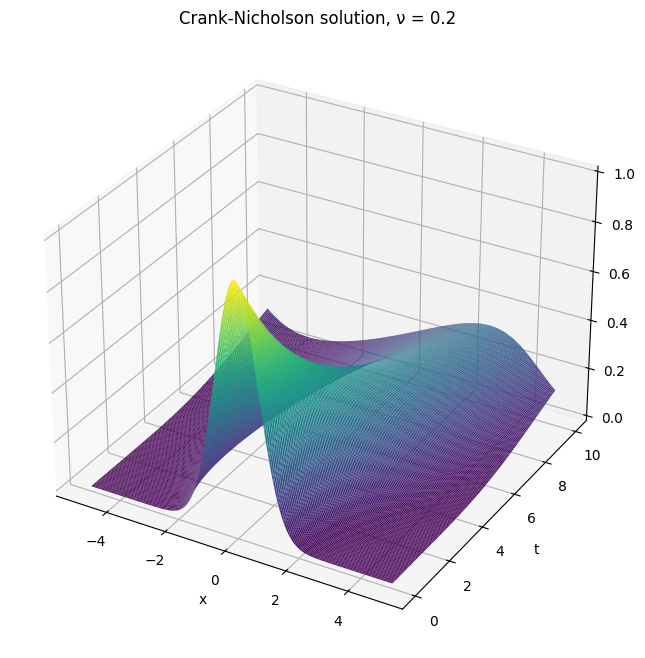

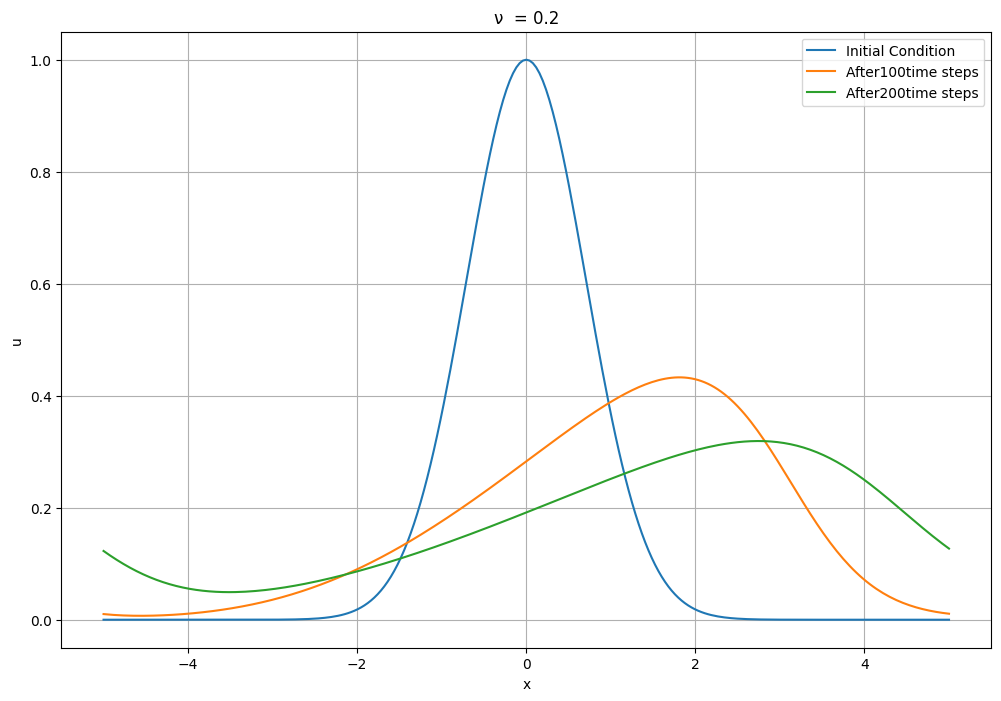

In [ ]:
nu = 0.2
u = CK_Burger(N, nu, T, M, L, GaussianInitial)
ax = plt.axes(projection='3d')
ax.plot_surface(x_grid, t_grid, u, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('Crank-Nicholson solution, ν = ' + str(nu));
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
plt.savefig('Burger3d_02')
plt.figure()
plt.plot(x,GaussianInitial(x), label='Initial Condition')
plt.plot(x, u[:, int(M/2)], label='After' + str(int(M/2))+ 'time steps')
plt.plot(x, u[:, M], label='After' + str(M) + 'time steps')
plt.legend()
plt.title('ν  = ' + str(nu))
plt.xlabel('x')
plt.ylabel('u')
plt.grid(True)
plt.savefig('Burger2d_02')
plt.show()

In [ ]:
Ut, R, rhs_des = build_linear_system(u, dt, dx, D=3, P=3, time_diff = 'FD', space_diff = 'FD')
['1'] + rhs_des[1:]
# Solve with STRidge
w = TrainSTRidge(R,Ut,10**-5,0.1)
print("PDE derived using STRidge")
print_pde(w, rhs_des)

PDE derived using STRidge
u_t = (-1.000166 +0.000000i)uu_{x}
    + (0.199643 +0.000000i)u_{xx}
   


/tmp/ipykernel_1398/2749661499.py:396: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pde = pde + "(%05f %+05fi)" % (w[i].real, w[i].imag) + rhs_description[i] + "\n   "


In [ ]:
err = abs((D - w[8])*100)
print("Parameter error:", err, '%')

Parameter error: [280.03566135] %


In [ ]:
err = abs(np.array([(-1 -  w[5])*100, (nu - w[8])*100/0.1]))
print("Error using PDE-FIND to identify Burger's equation:\n")
print("Mean parameter error:", np.mean(err), '%')
print("Standard deviation of parameter error:", np.std(err), '%')

Error using PDE-FIND to identify Burger's equation:

Mean parameter error: 0.18660229078318324 %
Standard deviation of parameter error: 0.17001116365858437 %


In [ ]:
def get_pde(w, rhs_description, ut = 'u_t'):
    pde = ut + ' = '
    first = True
    w = w.ravel() # Flatten coefficient vector into 1-D array
    for i in range(len(w)): # Loop through all candidate PDE coefficients
        if w[i] != 0:  # Only keep nonzero terms in discovered equation
            if not first:
                pde = pde + ' + '
            pde = pde + "(%05f %+05fi)" % (w[i].real, w[i].imag) + rhs_description[i] # Append coefficient and corresponding PDE term
            first = False
    return pde

In [ ]:
nu_values = [0.02, 0.2, 2.0]
nus = []
pdes = []
errs_mean = []
errs_std = []
errs_meanfloat = []
for nu in nu_values:
    nus.append(nu)
    u = CK_Burger(N, nu, T, M, L, GaussianInitial)
    # Build the regression system for PDE discovery
    Ut, R, rhs_des = build_linear_system(
        u, # Solution data matrix u(x,t)
        dt, # Time step size
        dx, # Spatial step size
        D=3, # Highest spatial derivative included: u_x, u_xx, u_xxx
        P=3, # Highest polynomial power of u included: 1, u, u^2, u^3
        time_diff='FD',
        space_diff='FD'
    )
    w = TrainSTRidge(R, Ut, 10**-5, 0.1)
    w = w.transpose()
    pde = get_pde(w, rhs_des)
    pdes.append(pde)
    err = abs(np.array([
        (-1 - w[0, 5]) * 100,
        (nu - w[0, 8]) * 100 / 0.1
    ]))
    errs_meanfloat.append(np.mean(err))
    errs_mean.append(str('%f' % np.mean(err)) + "%")
    errs_std.append(str('%f' % np.std(err)) + "%")
    print("--------------------------------------------------")
    print("nu:", nu)
    print("PDE:", pde)
    print("Mean parameter error:", errs_mean[-1])
    print("Standard deviation:", errs_std[-1])

--------------------------------------------------
nu: 0.02
PDE: u_t = (-1.057624 +0.000000i)uu_{x} + (0.283156 +0.000000i)u^2u_{x} + (-0.258473 +0.000000i)u^3u_{x} + (0.019123 +0.000000i)u_{xx}
Mean parameter error: 3.319489%
Standard deviation: 2.442957%
--------------------------------------------------
nu: 0.2
PDE: u_t = (-1.000166 +0.000000i)uu_{x} + (0.199643 +0.000000i)u_{xx}
Mean parameter error: 0.186602%
Standard deviation: 0.170011%
--------------------------------------------------
nu: 2.0
PDE: u_t = (0.000286 +0.000000i) + (-0.039955 +0.000000i)u + (0.296344 +0.000000i)u^2 + (-0.457437 +0.000000i)u^3 + (0.056596 +0.000000i)u_{x} + (-1.879838 +0.000000i)uu_{x} + (4.210464 +0.000000i)u^2u_{x} + (-6.025522 +0.000000i)u^3u_{x} + (2.046360 +0.000000i)u_{xx} + (-0.741660 +0.000000i)uu_{xx} + (2.220960 +0.000000i)u^2u_{xx} + (-1.751078 +0.000000i)u^3u_{xx} + (-0.008975 +0.000000i)u_{xxx} + (0.060372 +0.000000i)uu_{xxx} + (0.125388 +0.000000i)u^2u_{xxx} + (-0.664818 +0.000000i)u^3

In [ ]:
from pandas import option_context

data1 = {
  "ν": nus,
  "PDE": pdes,
     "Mean parameter error": errs_mean,
    "Standard deviation of parameter error":errs_std
}

with option_context('display.max_colwidth', None):
    #load data into a DataFrame object:
    nu_pde = pd.DataFrame(data1)
    nu_pde.to_excel("Burger.xlsx",
             sheet_name='nu')
    display(nu_pde)

,ν,PDE,Mean parameter error,Standard deviation of parameter error
0,0.02,u_t = (-1.057624 +0.000000i)uu_{x} + (0.283156 +0.000000i)u^2u_{x} + (-0.258473 +0.000000i)u^3u_{x} + (0.019123 +0.000000i)u_{xx},3.319489%,2.442957%
1,0.20,u_t = (-1.000166 +0.000000i)uu_{x} + (0.199643 +0.000000i)u_{xx},0.186602%,0.170011%
2,2.00,u_t = (0.000286 +0.000000i) + (-0.039955 +0.000000i)u + (0.296344 +0.000000i)u^2 + (-0.457437 +0.000000i)u^3 + (0.056596 +0.000000i)u_{x} + (-1.879838 +0.000000i)uu_{x} + (4.210464 +0.000000i)u^2u_{x} + (-6.025522 +0.000000i)u^3u_{x} + (2.046360 +0.000000i)u_{xx} + (-0.741660 +0.000000i)uu_{xx} + (2.220960 +0.000000i)u^2u_{xx} + (-1.751078 +0.000000i)u^3u_{xx} + (-0.008975 +0.000000i)u_{xxx} + (0.060372 +0.000000i)uu_{xxx} + (0.125388 +0.000000i)u^2u_{xxx} + (-0.664818 +0.000000i)u^3u_{xxx},67.171921%,20.811909%


,ν,Mean parameter error,Standard deviation of parameter error
0,0.02,3.319489%,2.442957%
1,0.20,0.186602%,0.170011%
2,2.00,67.171921%,20.811909%


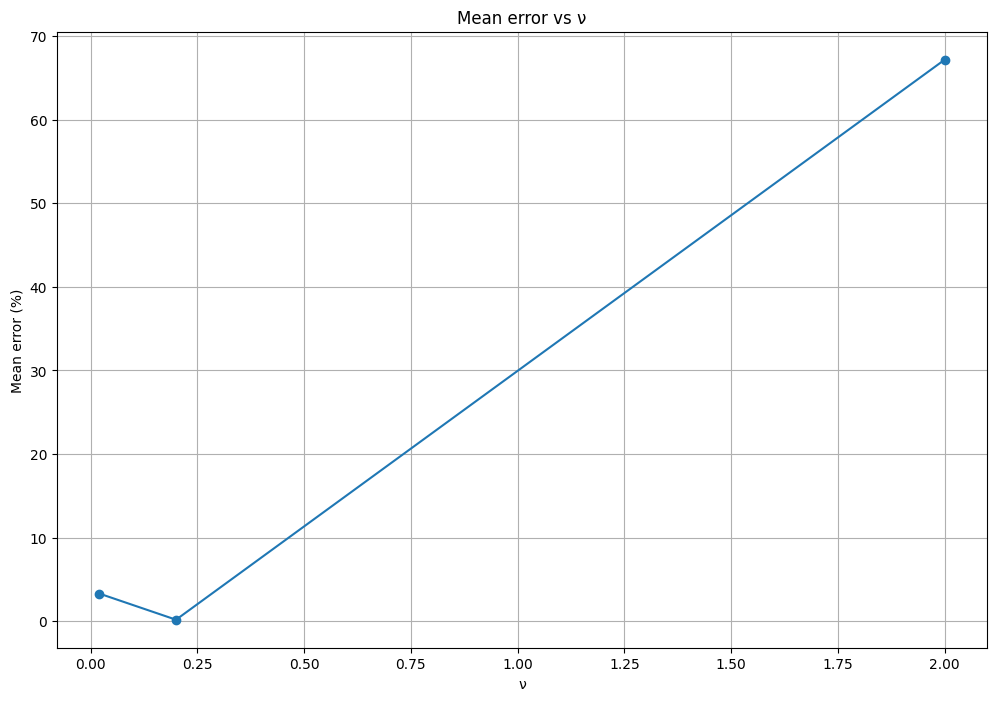

In [ ]:
data2 = {
  "ν": nus,
  "Mean parameter error": errs_mean,
    "Standard deviation of parameter error":errs_std
}

#load data into a DataFrame object:
nu_err = pd.DataFrame(data2)
#nu_err.to_excel("Burger.xlsx",
#             sheet_name='err')
display(nu_err)
plt.figure()
plt.plot(nus,errs_meanfloat, '-o')
plt.title('Mean error vs ν' )
plt.xlabel('ν')
plt.ylabel('Mean error (%)')
plt.grid(True)
plt.savefig('Error_nu.png')
plt.show()


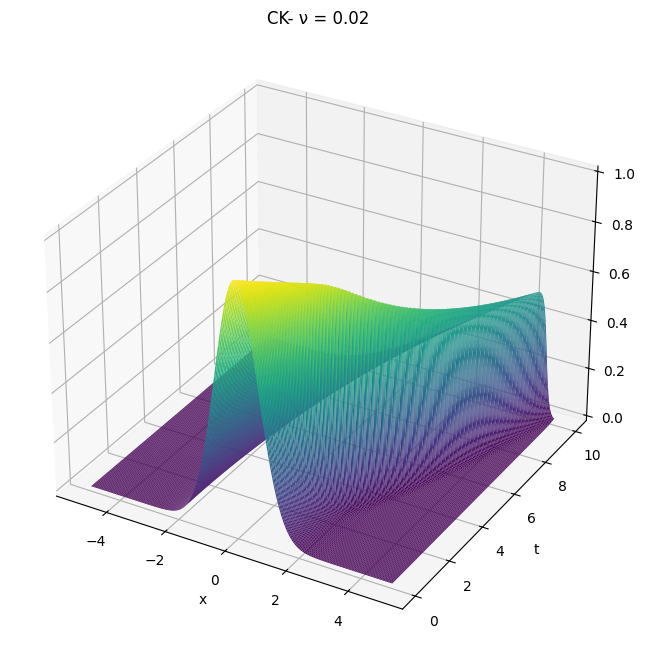

In [ ]:
nu1 = 0.02
nu2 = 0.2
nu3 = 2

T = 10
M = 256 # number of time grids
N = 200 # number of spatial steps
L = 10
dx = L/N
dt = T/M
D = 3
P = 3

x = np.linspace(-L/2, L/2, N+1)
t = np.linspace(0, T, M+1)
t_grid, x_grid = np.meshgrid(t,x)
u_initial = sinInitial(x)
Ma = max(u_initial)
u1 = CK_Burger(N, nu1, T, M, L, GaussianInitial)

ax = plt.axes(projection='3d')
ax.plot_surface(x_grid, t_grid, u1, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('CK- ν = ' + str(nu1));
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
plt.savefig('Burger3d_004.png')

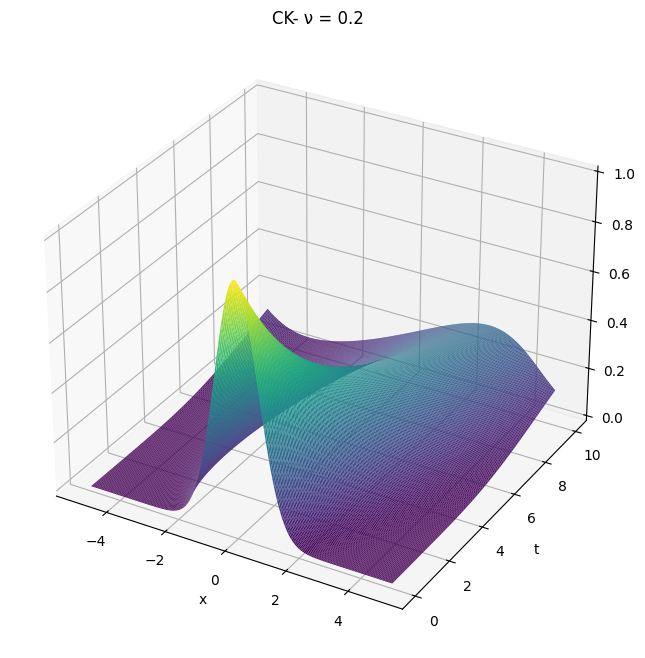

In [ ]:
u2 = CK_Burger(N, nu2, T, M, L, GaussianInitial)
u3 = CK_Burger(N, nu3, T, M, L, GaussianInitial)
ax = plt.axes(projection='3d')
ax.plot_surface(x_grid, t_grid, u2, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('CK- ν = ' + str(nu2));
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
plt.savefig('Burger3d_004.png')

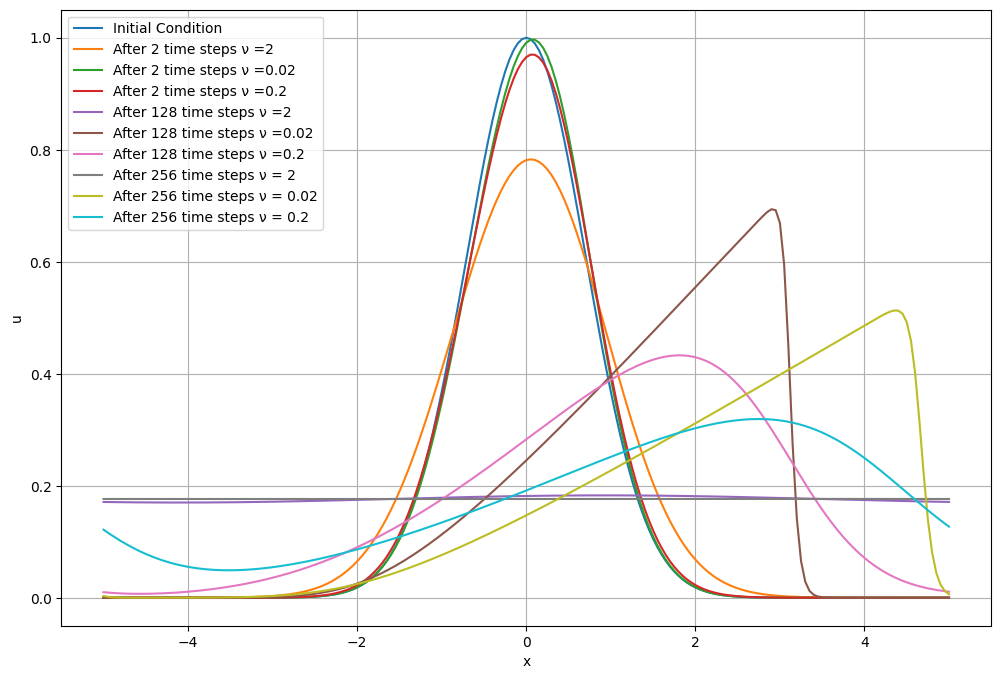

In [ ]:
plt.figure()
plt.plot(x,GaussianInitial(x), label='Initial Condition')
plt.plot(x, u3[:, 2], label='After' + ' 2 '+ 'time steps ν =' + str(nu3))
plt.plot(x, u1[:, 2], label='After' + ' 2 '+ 'time steps ν =' + str(nu1))
plt.plot(x, u2[:, 2], label='After' + ' 2 '+ 'time steps ν =' + str(nu2))
plt.plot(x, u3[:, int(M/2)], label='After ' + str(int(M/2))+ ' time steps ν =' + str(nu3))
plt.plot(x, u1[:, int(M/2)], label='After ' + str(int(M/2))+ ' time steps ν =' + str(nu1))
plt.plot(x, u2[:, int(M/2)], label='After ' + str(int(M/2))+ ' time steps ν =' + str(nu2))
plt.plot(x, u3[:, M], label='After ' + str(M) + ' time steps ν = ' + str(nu3))
plt.plot(x, u1[:, M], label='After ' + str(M) + ' time steps ν = ' + str(nu1))
plt.plot(x, u2[:, M], label='After ' + str(M) + ' time steps ν = ' + str(nu2))
plt.legend()
plt.xlabel('x')
plt.ylabel('u')
plt.grid(True)
plt.savefig('Burger2d_002004.png')
plt.show()

As we can see from the table, PDE-FIND retrieves the correct terms for $\nu$ ranging from $0.04$ to $0.36$ and the parameter discovered is close to the exact parameters.
In this range, the graph is relatively smooth.  
The graph above shows that a shock wave is formed roughly between $\nu = 0.02$ and $\nu = 0.03$, which is the cut-off point of the failure of `PDE-FIND`.

### Adding Noise
#### Finite differences
We now choose $\nu = 0.20$ which falls within the range where `PDE-FIND` gives accurate result, and try adding noises to the function to see if PDE-FIND can still give the right result. Here we continue to use finite difference for derivative approximation.

In [ ]:
nu = 0.20
u = CK_Burger(N, nu, T, M, L, GaussianInitial)


In [ ]:
Ut, R, rhs_des = build_linear_system(u, dt, dx, D=3, P=3, time_diff = 'FD', space_diff = 'FD')
['1'] + rhs_des[1:]
# Solve with STRidge
w = TrainSTRidge(R,Ut,10**-5,0.1)
print("PDE derived using STRidge without noise")
print_pde(w, rhs_des)

PDE derived using STRidge without noise
u_t = (-1.000038 +0.000000i)uu_{x}
    + (0.199749 +0.000000i)u_{xx}
   


/tmp/ipykernel_1398/2749661499.py:396: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pde = pde + "(%05f %+05fi)" % (w[i].real, w[i].imag) + rhs_description[i] + "\n   "


In [ ]:
err = abs(np.array([(-1 -  w[5])*100, (nu - w[8])*100/0.1]))
print("Error using PDE-FIND to identify Burger's equation:\n")
print("Mean parameter error:", np.mean(err), '%')
print("Standard deviation of parameter error:", np.std(err), '%')

Error using PDE-FIND to identify Burger's equation:

Mean parameter error: 0.1271821893269076 %
Standard deviation of parameter error: 0.12343202478036219 %


**Introduce noises levels from $10^{-6}$ to $1$**

In [ ]:
lams = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1,1])
ws = np.empty(((D+1)*(P+1), 1))
pdes = np.empty((0, 7), str)
errs_mean = []
errs_std =[]
errs_meanfloat = []

for lam in lams:
    np.random.seed(0)
    un = u + lam*np.std(u)*np.random.randn(u.shape[0],u.shape[1])
    #u = CK_Burger(N, nu, T, M, L, GaussianInitial)
    Utn, Rn, rhs_des = build_linear_system(un, dt, dx, D=3, P=3, time_diff = 'FD', space_diff = 'FD')
    ['1'] + rhs_des[1:]

    # Solve with STRidge
    w = TrainSTRidge(Rn,Utn,10**-5,0.1)
    w = w.transpose()
    ws = np.append(ws, w)
    pde = get_pde(w, rhs_des)
    pdes = np.append(pdes, pde)
    err = abs(np.array([(-1 -  w[0,5])*100, (nu - w[0,8])*100/0.1]))
    errs_meanfloat = np.append(errs_meanfloat, np.mean(err))
    me = str('%f' % np.mean(err)) + "%"
    st = str('%f' %np.std(err)) + "%"
    errs_mean = np.append(errs_mean, me)
    errs_std = np.append(errs_std, st)


In [ ]:
data1 = {
  "λ": lams,
  "PDE": pdes,
     "Mean parameter error": errs_mean,
   "Standard deviation of parameter error":errs_std
}

with option_context('display.max_colwidth', None):
    #load data into a DataFrame object:
    lam_pde = pd.DataFrame(data1)
    lam_pde.to_excel("Burger.xlsx", sheet_name='noise')
    display(lam_pde)

,λ,PDE,Mean parameter error,Standard deviation of parameter error
0,0.000001,u_t = (-1.000039 +0.000000i)uu_{x} + (0.199750 +0.000000i)u_{xx},0.127185%,0.123310%
1,0.000010,u_t = (-1.000044 +0.000000i)uu_{x} + (0.199736 +0.000000i)u_{xx},0.133937%,0.129586%
2,0.000100,u_t = (-0.999500 +0.000000i)uu_{x} + (0.198224 +0.000000i)u_{xx},0.913115%,0.863086%
3,0.001000,u_t = (0.219123 +0.000000i)u + (-0.923587 +0.000000i)u^2 + (0.682835 +0.000000i)u^3 + (-0.173163 +0.000000i)u_{x} + (-0.284959 +0.000000i)uu_{x} + (-0.547503 +0.000000i)u^2u_{x} + (0.520867 +0.000000i)uu_{xx} + (-1.145580 +0.000000i)u^2u_{xx} + (0.852182 +0.000000i)u^3u_{xx},135.752029%,64.247971%
4,0.010000,u_t = (0.172602 +0.000000i)u + (-0.550072 +0.000000i)u^2 + (-0.141183 +0.000000i)u_{x} + (-0.759687 +0.000000i)uu_{x} + (0.938073 +0.000000i)u^2u_{x} + (-1.031921 +0.000000i)u^3u_{x},112.015666%,87.984334%
5,0.100000,u_t = (0.010143 +0.000000i) + (0.069416 +0.000000i)u + (-0.221787 +0.000000i)u^2 + (-0.287368 +0.000000i)u^3 + (0.008364 +0.000000i)u_{x} + (-0.405369 +0.000000i)uu_{x} + (-1.072230 +0.000000i)u^2u_{x} + (0.820787 +0.000000i)u^3u_{x} + (0.000158 +0.000000i)u_{xx} + (-0.005109 +0.000000i)uu_{xx} + (0.013394 +0.000000i)u^2u_{xx} + (-0.008248 +0.000000i)u^3u_{xx} + (-0.000004 +0.000000i)u_{xxx} + (0.000143 +0.000000i)uu_{xxx} + (-0.003028 +0.000000i)u^2u_{xxx} + (0.002418 +0.000000i)u^3u_{xxx},129.652344%,70.189293%
6,1.000000,u_t = (-0.001828 +0.000000i) + (-0.165900 +0.000000i)u + (1.524180 +0.000000i)u^2 + (-2.114571 +0.000000i)u^3 + (-0.000495 +0.000000i)u_{x} + (-0.002888 +0.000000i)uu_{x} + (0.278570 +0.000000i)u^2u_{x} + (-0.440682 +0.000000i)u^3u_{x} + (-0.000086 +0.000000i)u_{xx} + (0.000950 +0.000000i)uu_{xx} + (-0.003073 +0.000000i)u^2u_{xx} + (0.000780 +0.000000i)u^3u_{xx} + (-0.000009 +0.000000i)u_{xxx} + (0.000046 +0.000000i)uu_{xxx} + (0.000084 +0.000000i)u^2u_{xxx} + (-0.000212 +0.000000i)u^3u_{xxx},149.898682%,50.187508%


,λ,Mean parameter error,Standard deviation of parameter error
0,0.000001,0.127185%,0.123310%
1,0.000010,0.133937%,0.129586%
2,0.000100,0.913115%,0.863086%
3,0.001000,135.752029%,64.247971%
4,0.010000,112.015666%,87.984334%
5,0.100000,129.652344%,70.189293%
6,1.000000,149.898682%,50.187508%


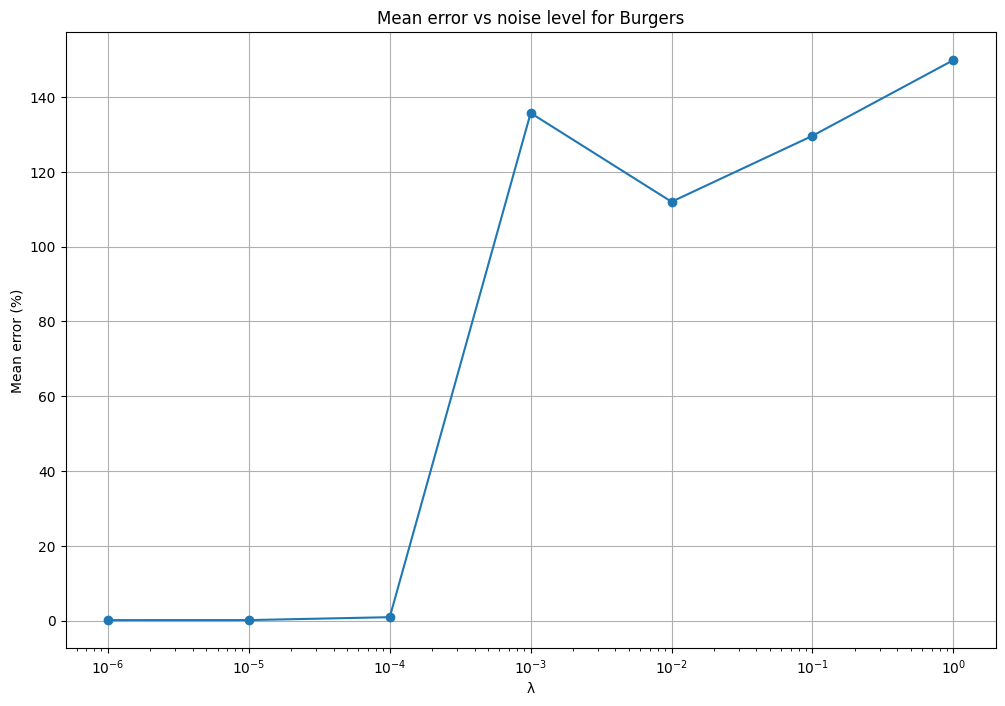

In [ ]:
data2 = {
    "λ": lams,
    "Mean parameter error": errs_mean,
    "Standard deviation of parameter error": errs_std
}

lam_err = pd.DataFrame(data2)
display(lam_err)

plt.figure()

plt.semilogx(
    lams,
    errs_meanfloat,
    '-o'
)

plt.title('Mean error vs noise level for Burgers')
plt.xlabel('λ')
plt.ylabel('Mean error (%)')
plt.grid(True)
plt.savefig('Error_Burger_noise.png')
plt.show()